In [2]:
!git clone https://github.com/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints.git

Cloning into 'Pneumonia-Detection-Under-Imaging-Constraints'...
remote: Enumerating objects: 5882, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 5882 (delta 3), reused 22 (delta 1), pack-reused 5853 (from 1)
Receiving objects: 100% (5882/5882), 1.16 GiB | 37.64 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (5876/5876), done.


In [3]:
import sys
import os

sys.path.append(os.path.abspath("src"))

In [8]:
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [9]:
import sys
print(sys.path[:5])

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']


In [2]:
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints
import sys
sys.path.append("/content/Pneumonia-Detection-Under-Imaging-Constraints")
from src.pixel_size_degradation import create_resolution_dataloaders

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [5]:
!pwd

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [6]:
!ls src

dataset_generation.py  pixel_size_degradation.py  __pycache__


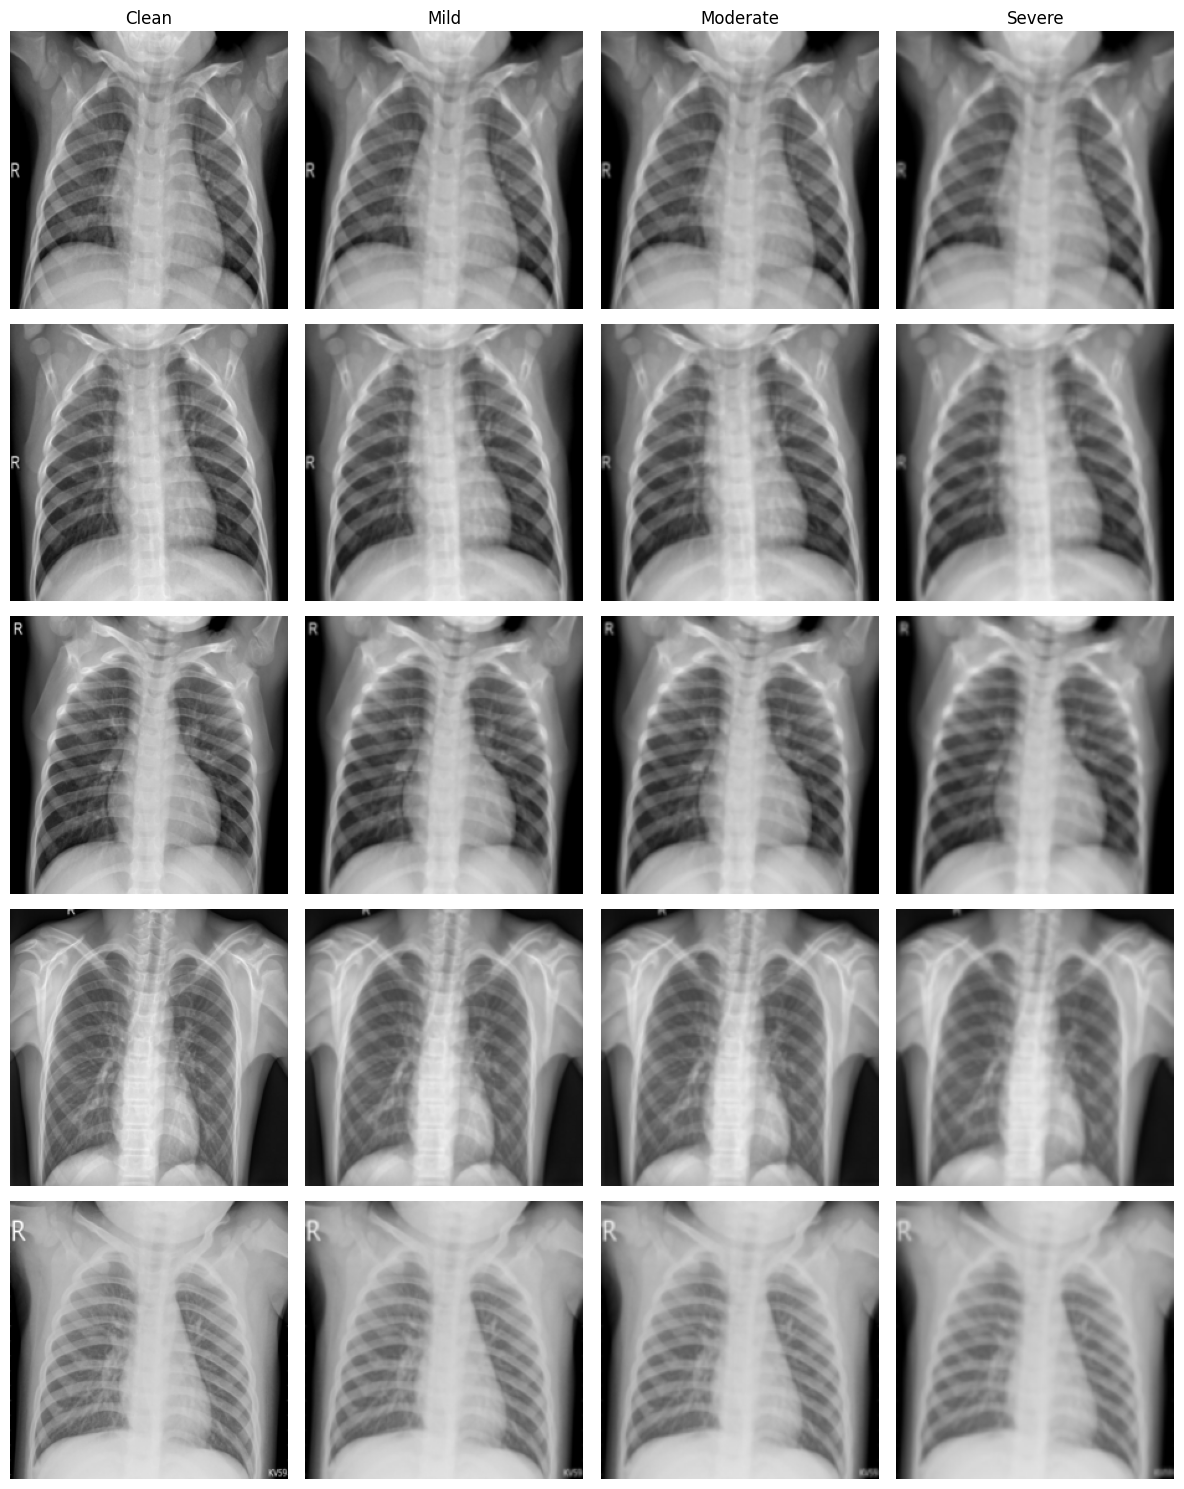

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Import your dataset generator
# -----------------------------------
from src.pixel_size_degradation import create_resolution_dataloaders

# -----------------------------------
# Load datasets
# -----------------------------------
base_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/data"

clean_loaders, degraded_loader_sets = create_resolution_dataloaders(
    base_path=base_path,
    batch_size=8,
    degradation_levels={
        "clean": 1.00,
        "mild": 0.85,
        "moderate": 0.70,
        "severe": 0.50,
    }
)

# -----------------------------------
# Helper: unnormalize for plotting
# -----------------------------------
def unnormalize(img):
    img = img * 0.5 + 0.5  # assuming Normalize((0.5,), (0.5,))
    return np.clip(img, 0, 1)

# -----------------------------------
# Get ONE batch (same indices across datasets)
# -----------------------------------
clean_batch = next(iter(clean_loaders["test"]))
images_clean, labels = clean_batch

# grab matching degraded batches
images_mild = next(iter(degraded_loader_sets["mild"]["test"]))[0]
images_moderate = next(iter(degraded_loader_sets["moderate"]["test"]))[0]
images_severe = next(iter(degraded_loader_sets["severe"]["test"]))[0]

# -----------------------------------
# Plot comparison
# -----------------------------------
num_images = 5  # how many samples to show

fig, axes = plt.subplots(num_images, 4, figsize=(12, 3 * num_images))

titles = ["Clean", "Mild", "Moderate", "Severe"]

for i in range(num_images):
    imgs = [
        images_clean[i],
        images_mild[i],
        images_moderate[i],
        images_severe[i],
    ]

    for j in range(4):
        img = imgs[j].permute(1, 2, 0).cpu().numpy()
        img = unnormalize(img)

        axes[i, j].imshow(img.squeeze(), cmap="gray")
        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(titles[j])

plt.tight_layout()
plt.show()

In [4]:
import os
import torch
import torch.nn as nn
from torchvision.models import densenet121

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Rebuild model architecture
# -----------------------------
model = densenet121(weights=None)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)
model = model.to(device)

# -----------------------------
# Load saved weights
# -----------------------------
weights_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/results/baseline_densenet_classweighted/model_weights.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Model weights loaded successfully.")

Using device: cuda
Model weights loaded successfully.


In [5]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model_full(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [6]:
import numpy as np

# example: from your train set counts
num_normal = 1341
num_pneumonia = 3875
total = num_normal + num_pneumonia

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

class_weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [7]:
import pandas as pd

results = []

for level_name, loader_set in degraded_loader_sets.items():
    test_loader = loader_set["test"]

    metrics = evaluate_model_full(model, test_loader, criterion, device)

    results.append({
        "degradation_level": level_name,
        "scale_factor": loader_set["scale_factor"],
        "loss": metrics["loss"],
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
    })

results_df = pd.DataFrame(results).sort_values("scale_factor", ascending=False)
results_df

,degradation_level,scale_factor,loss,accuracy,balanced_accuracy,precision,recall,f1,auc
0,clean,1.00,0.787996,0.793269,0.729487,0.757396,0.984615,0.856187,0.933591
1,mild,0.85,1.060845,0.740385,0.657265,0.709559,0.989744,0.826552,0.924118
2,moderate,0.70,1.164112,0.727564,0.640171,0.699275,0.989744,0.819533,0.919220
3,severe,0.50,1.429287,0.695513,0.594872,0.673010,0.997436,0.803719,0.904049


In [8]:
print(results_df.to_string(index=False))

degradation_level  scale_factor     loss  accuracy  balanced_accuracy  precision   recall       f1      auc
            clean          1.00 0.787996  0.793269           0.729487   0.757396 0.984615 0.856187 0.933591
             mild          0.85 1.060845  0.740385           0.657265   0.709559 0.989744 0.826552 0.924118
         moderate          0.70 1.164112  0.727564           0.640171   0.699275 0.989744 0.819533 0.919220
           severe          0.50 1.429287  0.695513           0.594872   0.673010 0.997436 0.803719 0.904049


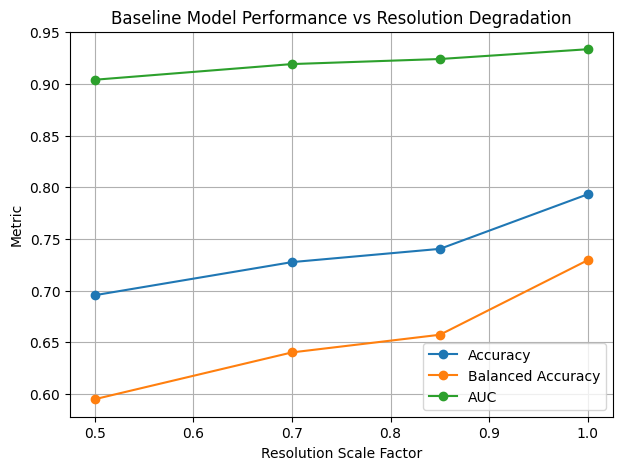

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(results_df["scale_factor"], results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["scale_factor"], results_df["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(results_df["scale_factor"], results_df["auc"], marker="o", label="AUC")

plt.xlabel("Resolution Scale Factor")
plt.ylabel("Metric")
plt.title("Baseline Model Performance vs Resolution Degradation")
plt.legend()
plt.grid(True)
plt.show()